# Visualization of Fail-Safe N (FSN) Maps

This section focuses on visualizing the generated FSN datasets.

**Core Workflow:**
1. **Load Mask**: Construct a binarized mask using the generated Z-thresholded significance outcome maps from the ALE results.
2. **Read & Calculate**: Read the mean FSN map for the corresponding analysis group to calculate the FSN percentage relative to the number of original studies included (`(FSN / N_studies) * 100`).
3. **Render Visualization**: Render a transparent 3D glass brain with orthogonal views (Left/Right, Top, Back) using `nilearn` and add a standalone colorbar representing normalized percentages.

In [1]:
# Import necessary modules
from os import makedirs, path
from atlasreader import get_statmap_info
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
from nilearn import image, plotting, reporting
from scipy import stats
from scipy.stats import pearsonr
import os, fnmatch
from glob import glob
from pathlib import Path
import re
import matplotlib as mpl
from nilearn import plotting, image
import numpy as np
from nimare import correct, io, meta, utils

# print the current working directory
# print(os.getcwd())

The Python package you are importing, AtlasReader, is licensed under the
BSD-3 license; however, the atlases it uses are separately licensed under more
restrictive frameworks.
By using AtlasReader, you agree to abide by the license terms of the
individual atlases. Information on these terms can be found online at:
https://github.com/miykael/atlasreader/tree/master/atlasreader/data



INFO:arviz:Found 'auto' as default backend, checking available backends
INFO:arviz:Matplotlib is available, defining as default backend
INFO:arviz.preview:arviz_base available, exposing its functions as part of arviz.preview
INFO:arviz.preview:arviz_stats available, exposing its functions as part of arviz.preview
INFO:arviz.preview:arviz_plots available, exposing its functions as part of arviz.preview


/Users/ss/miniconda3/lib/python3.12/site-packages/nilearn/image/image.py:1160: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  return new_img_like(niimg, result, niimg.affine)


formula: img1 * img2 / 18
img_perc.shape: (91, 109, 91)


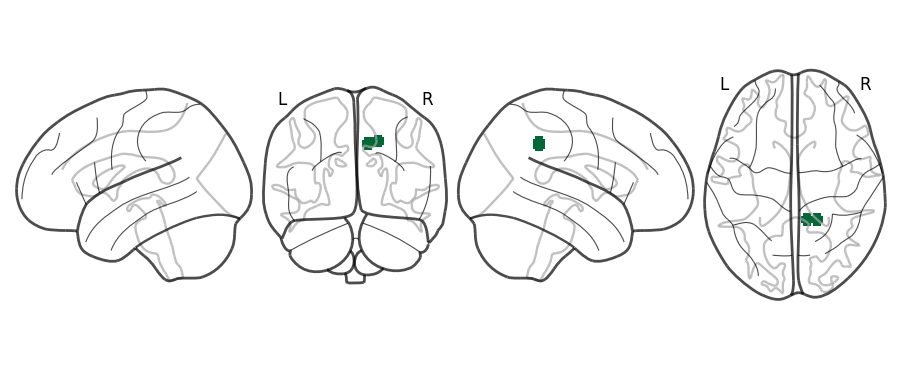

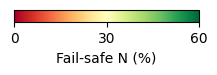

In [29]:
# define the colorbar range for the FSN percentage  
vmin, vmax = 0, 60 

# define the input text file and output directory for the current analysis
img_task = image.load_img("../3_Output/1_ALE/hypoactivation_z_size_level_thresh.nii.gz") 
img_mask = image.math_img("np.where(img > 0, 100, 0)", img=img_task)  
img_fsn = image.load_img("../3_Output/7_FSN/hypoactivation/hypoactivation_mean_fsn.nii.gz") 

# define the number of original studies for the current analysis
n_studies = 18

# Calculate the FSN percentage
formula = f"img1 * img2 / {n_studies}"  
img_perc = image.math_img(formula=formula, img1=img_fsn, img2=img_mask)

formula = "img1 * img2 / " + str(n_studies)
print(f'formula: {formula}') 

img_perc = image.math_img(formula=formula, img1=img_fsn, img2=img_mask)
print(f'img_perc.shape: {img_perc.shape}')

p = plotting.plot_glass_brain(None, display_mode="lyrz")
p.add_overlay(img_perc, cmap="RdYlGn", vmin=vmin, vmax=vmax)

# Add colorbar
fig1 = plt.figure(figsize=(12, 6)) 
gs = fig1.add_gridspec(110, 90) 
ax_cbar = fig1.add_subplot(gs[100:103, 36:54])
cmap = plt.get_cmap("RdYlGn")
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
fg1 = mpl.colorbar.ColorbarBase(
        ax_cbar,
        cmap=cmap,
        norm=norm,
        orientation="horizontal",
        ticks=[vmin, vmax, (vmin + vmax) / 2],
        label="Fail-safe N (%)",
    )

/Users/ss/miniconda3/lib/python3.12/site-packages/nilearn/image/image.py:1160: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  return new_img_like(niimg, result, niimg.affine)


formula: img1 * img2 / 24
img_perc.shape: (91, 109, 91)


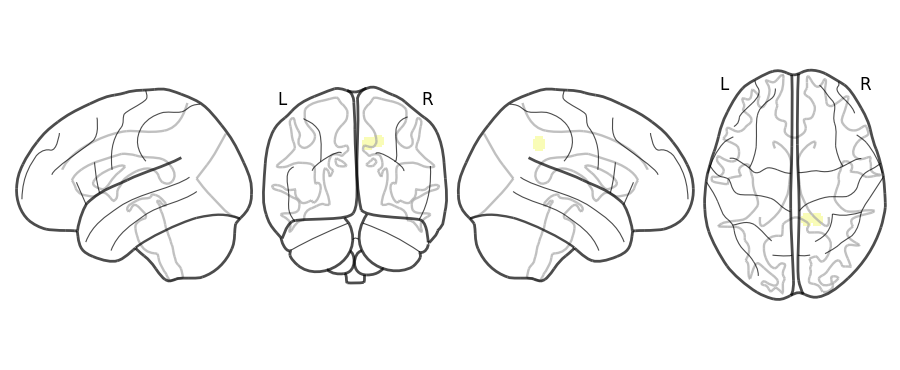

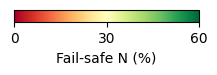

In [2]:
# define the colorbar range for the FSN percentage  
vmin, vmax = 0, 60 

# define the input text file and output directory for the current analysis
img_task = image.load_img("../3_Output/1_ALE/hyper_and_hypo_z_size_level_thresh.nii.gz") 
img_mask = image.math_img("np.where(img > 0, 100, 0)", img=img_task)  
img_fsn = image.load_img("../3_Output/7_FSN/hyper_and_hypo/hyper_and_hypo_mean_fsn.nii.gz") 

# define the number of original studies for the current analysis
n_studies = 24

# Calculate the FSN percentage
formula = f"img1 * img2 / {n_studies}"  
img_perc = image.math_img(formula=formula, img1=img_fsn, img2=img_mask)

formula = "img1 * img2 / " + str(n_studies)
print(f'formula: {formula}') 

img_perc = image.math_img(formula=formula, img1=img_fsn, img2=img_mask)
print(f'img_perc.shape: {img_perc.shape}')

p = plotting.plot_glass_brain(None, display_mode="lyrz")
p.add_overlay(img_perc, cmap="RdYlGn", vmin=vmin, vmax=vmax)

# Add colorbar
fig2 = plt.figure(figsize=(12, 6)) 
gs = fig2.add_gridspec(110, 90) 
ax_cbar = fig2.add_subplot(gs[100:103, 36:54])
cmap = plt.get_cmap("RdYlGn")
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
fig2 = mpl.colorbar.ColorbarBase(
        ax_cbar,
        cmap=cmap,
        norm=norm,
        orientation="horizontal",
        ticks=[vmin, vmax, (vmin + vmax) / 2],
        label="Fail-safe N (%)",
    )